In [1]:
# --- CELL 1: LIBRARY IMPORT & RAW DATA LOADING - INSTALLMENTS_PAYMENTS ---

import os
import gc
import pandas as pd

# 1. Định nghĩa đường dẫn file thô
raw_ins_path = '/Users/nguyenminhtri/FinalYearPro/data/raw/installments_payments.csv'

print(f"📥 Loading raw installments_payments dataset from: {raw_ins_path}")
df_ins = pd.read_csv(raw_ins_path)

print("=" * 65)
print(f"📊 Raw Dataset Dimensions : {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")
print(f"💾 Initial RAM Usage      : {df_ins.memory_usage().sum() / 1024 ** 2:.2f} MB")
print("=" * 65)

# 2. Kiểm tra danh sách cột, kiểu dữ liệu và tỷ lệ thiếu (Missing rate)
info_df = pd.DataFrame({
    'Data Type': df_ins.dtypes,
    'Null Count': df_ins.isnull().sum(),
    'Null Ratio (%)': (df_ins.isnull().sum() / len(df_ins)) * 100
})

print("\n🔍 THÔNG TIN CHI TIẾT 8 CỘT GỐC:")
print(info_df)

# Hiển thị 5 dòng đầu
df_ins.head()


📥 Loading raw installments_payments dataset from: /Users/nguyenminhtri/FinalYearPro/data/raw/installments_payments.csv
📊 Raw Dataset Dimensions : 13,605,401 rows | 8 columns
💾 Initial RAM Usage      : 830.41 MB

🔍 THÔNG TIN CHI TIẾT 8 CỘT GỐC:
                       Data Type  Null Count  Null Ratio (%)
SK_ID_PREV                 int64           0        0.000000
SK_ID_CURR                 int64           0        0.000000
NUM_INSTALMENT_VERSION   float64           0        0.000000
NUM_INSTALMENT_NUMBER      int64           0        0.000000
DAYS_INSTALMENT          float64           0        0.000000
DAYS_ENTRY_PAYMENT       float64        2905        0.021352
AMT_INSTALMENT           float64           0        0.000000
AMT_PAYMENT              float64        2905        0.021352


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [2]:
# --- CELL 2: PREPROCESSING & FEATURE ENGINEERING - NUM_INSTALMENT_VERSION ---

print("⏳ Engineering features for NUM_INSTALMENT_VERSION...")

# 1. Flexible Credit Card / Revolving Loan indicator flag (Version == 0.0)
df_ins['INS_IS_CREDIT_CARD'] = (df_ins['NUM_INSTALMENT_VERSION'] == 0.0).astype(int)

# 2. Standard Contract Schedule indicator flag (Version == 1.0)
df_ins['INS_IS_STANDARD_SCHEDULE'] = (df_ins['NUM_INSTALMENT_VERSION'] == 1.0).astype(int)

# 3. Restructured / Amended Contract Schedule indicator flag (Version > 1.0)
df_ins['INS_IS_RESTRUCTURED'] = (df_ins['NUM_INSTALMENT_VERSION'] > 1.0).astype(int)

print("✅ Successfully processed NUM_INSTALMENT_VERSION!")
print(
    f"   • Revolving / Credit Card installment entries (Version == 0) : {df_ins['INS_IS_CREDIT_CARD'].sum():,} ({df_ins['INS_IS_CREDIT_CARD'].mean() * 100:.2f}%)")
print(
    f"   • Standard contract installment entries (Version == 1)   : {df_ins['INS_IS_STANDARD_SCHEDULE'].sum():,} ({df_ins['INS_IS_STANDARD_SCHEDULE'].mean() * 100:.2f}%)")
print(
    f"   • Restructured / Amended installment entries (Version > 1) : {df_ins['INS_IS_RESTRUCTURED'].sum():,} ({df_ins['INS_IS_RESTRUCTURED'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")


⏳ Engineering features for NUM_INSTALMENT_VERSION...
✅ Successfully processed NUM_INSTALMENT_VERSION!
   • Revolving / Credit Card installment entries (Version == 0) : 4,082,498 (30.01%)
   • Standard contract installment entries (Version == 1)   : 8,485,004 (62.36%)
   • Restructured / Amended installment entries (Version > 1) : 1,037,899 (7.63%)
📊 Current dataset shape: 13,605,401 rows | 11 columns


### 📌 Preprocessing & Feature Engineering: `NUM_INSTALMENT_VERSION` (Installment Schedule Version)

- **Action Taken:**
  1. Formulated revolving credit/credit card indicator flag: `INS_IS_CREDIT_CARD` (`NUM_INSTALMENT_VERSION == 0.0`).
  2. Formulated baseline standard contract schedule flag: `INS_IS_STANDARD_SCHEDULE` (`NUM_INSTALMENT_VERSION == 1.0`).
  3. Formulated restructured/amended schedule indicator flag: `INS_IS_RESTRUCTURED` (`NUM_INSTALMENT_VERSION > 1.0`).
  4. Preserved raw continuous `NUM_INSTALMENT_VERSION` to enable downstream client-level aggregations (`NUNIQUE`, `MAX`) capturing total schedule modification frequency.

- **Rationale:**
  - `NUM_INSTALMENT_VERSION` exhibits structural bimodal peaks at `0.0` (revolving credit card lines) and `1.0` (standard fixed installment loans).
  - Version increments above `1.0` signal contractual modifications, debt restructuring, or tenor extensions—serving as strong behavioral risk proxies for borrower financial distress.

📊 BẢNG THỐNG KÊ MÔ TẢ: NUM_INSTALMENT_NUMBER
                 Metric      Value
  Count (Số lượng dòng) 13,605,401
      Mean (Trung bình)      18.87
      Median (Trung vị)       8.00
          Mode (Yếu vị)       1.00
Std Dev (Độ lệch chuẩn)      26.66
        Min (Tối thiểu)       1.00
           Max (Tối đa)     277.00
       IQR (Tứ phân vị)      15.00


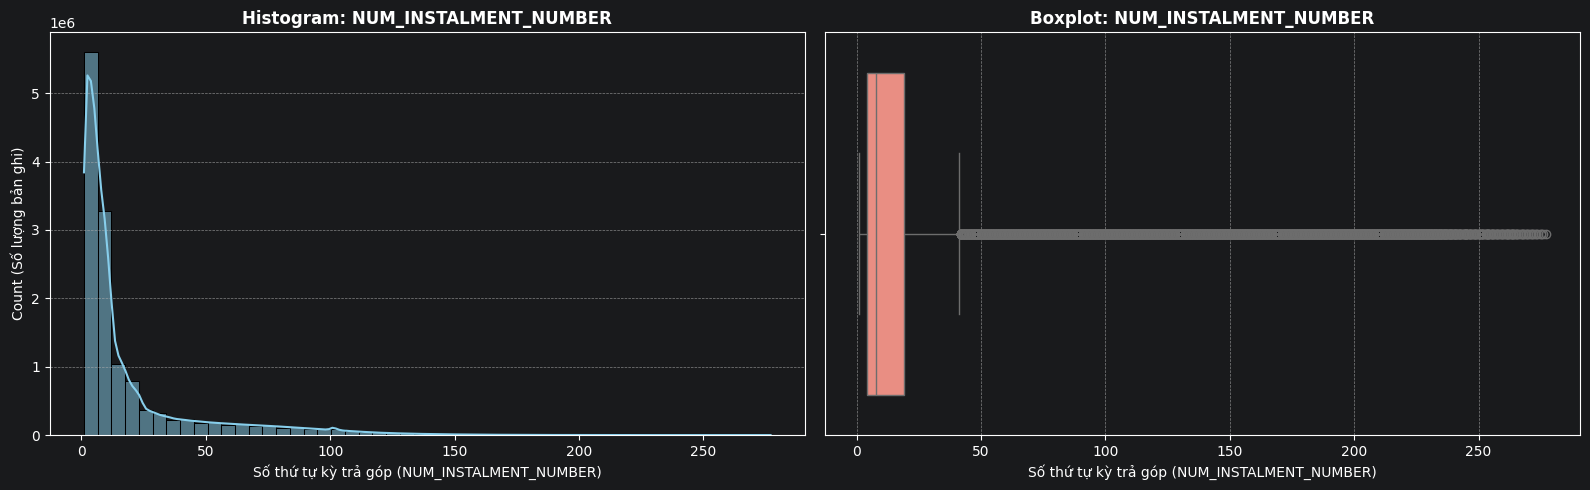

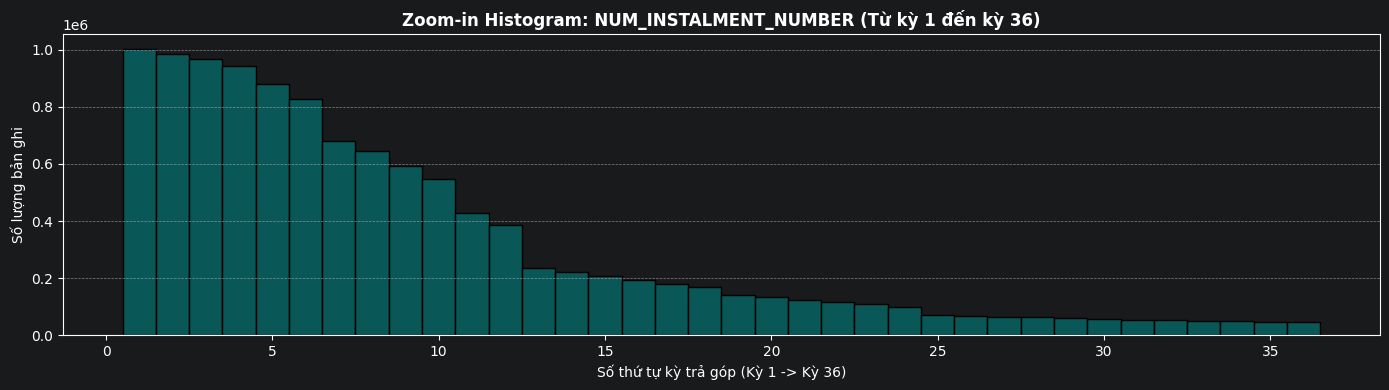

In [3]:
# --- EXPLORATORY DATA ANALYSIS: NUM_INSTALMENT_NUMBER ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Tính toán các thông số thống kê mô tả
col_data = df_ins['NUM_INSTALMENT_NUMBER'].dropna()

stats_summary = pd.DataFrame({
    'Metric': [
        'Count (Số lượng dòng)',
        'Mean (Trung bình)',
        'Median (Trung vị)',
        'Mode (Yếu vị)',
        'Std Dev (Độ lệch chuẩn)',
        'Min (Tối thiểu)',
        'Max (Tối đa)',
        'IQR (Tứ phân vị)'
    ],
    'Value': [
        f"{len(col_data):,}",
        f"{col_data.mean():.2f}",
        f"{col_data.median():.2f}",
        f"{col_data.mode()[0]:.2f}",
        f"{col_data.std():.2f}",
        f"{col_data.min():.2f}",
        f"{col_data.max():.2f}",
        f"{col_data.quantile(0.75) - col_data.quantile(0.25):.2f}"
    ]
})

print("📊 BẢNG THỐNG KÊ MÔ TẢ: NUM_INSTALMENT_NUMBER")
print(stats_summary.to_string(index=False))

# 2. Vẽ đồ thị Histogram và Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram (Phân phối tần suất)
sns.histplot(col_data, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram: NUM_INSTALMENT_NUMBER', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số thứ tự kỳ trả góp (NUM_INSTALMENT_NUMBER)')
axes[0].set_ylabel('Count (Số lượng bản ghi)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot (Phát hiện Outliers)
sns.boxplot(x=col_data, ax=axes[1], color='salmon')
axes[1].set_title('Boxplot: NUM_INSTALMENT_NUMBER', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số thứ tự kỳ trả góp (NUM_INSTALMENT_NUMBER)')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Zoom-in cận cảnh phân phối ở các khoảng kỳ phổ biến (1 đến 36 kỳ)
plt.figure(figsize=(14, 4))
sns.histplot(col_data[col_data <= 36], discrete=True, color='teal', alpha=0.6)
plt.title('Zoom-in Histogram: NUM_INSTALMENT_NUMBER (Từ kỳ 1 đến kỳ 36)', fontsize=12, fontweight='bold')
plt.xlabel('Số thứ tự kỳ trả góp (Kỳ 1 -> Kỳ 36)')
plt.ylabel('Số lượng bản ghi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# --- CELL 3: PREPROCESSING & FEATURE ENGINEERING - NUM_INSTALMENT_NUMBER ---

print("⏳ Engineering features for NUM_INSTALMENT_NUMBER...")

# 1. Early stage installment indicator flag (First 6 installment cycles)
df_ins['INS_IS_INITIAL_STAGE'] = (df_ins['NUM_INSTALMENT_NUMBER'] <= 6).astype(int)

# 2. Mature / Long-term installment indicator flag (Cycles strictly beyond 24)
df_ins['INS_IS_MATURE_STAGE'] = (df_ins['NUM_INSTALMENT_NUMBER'] > 24).astype(int)

print("✅ Successfully processed NUM_INSTALMENT_NUMBER!")
print(
    f"   • Early-stage installment cycles (<= 6)  : {df_ins['INS_IS_INITIAL_STAGE'].sum():,} ({df_ins['INS_IS_INITIAL_STAGE'].mean() * 100:.2f}%)")
print(
    f"   • Mature/Long-term cycles (> 24)          : {df_ins['INS_IS_MATURE_STAGE'].sum():,} ({df_ins['INS_IS_MATURE_STAGE'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")

⏳ Engineering features for NUM_INSTALMENT_NUMBER...
✅ Successfully processed NUM_INSTALMENT_NUMBER!
   • Early-stage installment cycles (<= 6)  : 5,609,637 (41.23%)
   • Mature/Long-term cycles (> 24)          : 2,781,647 (20.45%)
📊 Current dataset shape: 13,605,401 rows | 13 columns


### 📌 Preprocessing & Feature Engineering: `NUM_INSTALMENT_NUMBER` (Installment Cycle Number)

- **Action Taken:**
  1. Formulated initial contract stage indicator flag: `INS_IS_INITIAL_STAGE` (`NUM_INSTALMENT_NUMBER <= 6`).
  2. Formulated mature/long-term contract stage indicator flag: `INS_IS_MATURE_STAGE` (`NUM_INSTALMENT_NUMBER > 24`).
  3. Preserved raw continuous `NUM_INSTALMENT_NUMBER` to support downstream client-level aggregations (`MAX`, `MEAN`) capturing historical loan tenor depth.

- **Rationale:**
  - `NUM_INSTALMENT_NUMBER` displays an extreme right-skewed distribution centered at early installment numbers (Median = 8.0, Mode = 1.0) with a long tail extending up to 277 cycles.
  - Isolating early installment cycles ($\le 6$) captures first-payment default (FPD) behavioral patterns, whereas mature cycles ($> 24$) highlight sustained long-term repayment commitments.

In [5]:
# --- CELL 4: PREPROCESSING & FEATURE ENGINEERING - DAYS_INSTALMENT ---

import numpy as np

print("⏳ Engineering features for DAYS_INSTALMENT (Standardized Monthly Windows)...")

# 1. Convert negative relative days to relative monthly index
df_ins['INS_MONTHS_INSTALMENT'] = (df_ins['DAYS_INSTALMENT'] / 30.4375).astype(int)

# 2. Construct standardized multi-window recency binary indicator flags
# 6 Months window (>= -180 days)
df_ins['INS_IS_RECENT_6M'] = (df_ins['DAYS_INSTALMENT'] >= -180).astype(int)

# 12 Months window (>= -365 days)
df_ins['INS_IS_RECENT_12M'] = (df_ins['DAYS_INSTALMENT'] >= -365).astype(int)

# 24 Months window (>= -730 days)
df_ins['INS_IS_RECENT_24M'] = (df_ins['DAYS_INSTALMENT'] >= -730).astype(int)

print("✅ Successfully processed DAYS_INSTALMENT with standardized monthly logic!")
print(
    f"   • Transactions within last 6 months (>= -180 days)  : {df_ins['INS_IS_RECENT_6M'].sum():,} ({df_ins['INS_IS_RECENT_6M'].mean() * 100:.2f}%)")
print(
    f"   • Transactions within last 12 months (>= -365 days) : {df_ins['INS_IS_RECENT_12M'].sum():,} ({df_ins['INS_IS_RECENT_12M'].mean() * 100:.2f}%)")
print(
    f"   • Transactions within last 24 months (>= -730 days) : {df_ins['INS_IS_RECENT_24M'].sum():,} ({df_ins['INS_IS_RECENT_24M'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")

⏳ Engineering features for DAYS_INSTALMENT (Standardized Monthly Windows)...
✅ Successfully processed DAYS_INSTALMENT with standardized monthly logic!
   • Transactions within last 6 months (>= -180 days)  : 1,660,583 (12.21%)
   • Transactions within last 12 months (>= -365 days) : 3,446,260 (25.33%)
   • Transactions within last 24 months (>= -730 days) : 6,285,099 (46.20%)
📊 Current dataset shape: 13,605,401 rows | 17 columns


### 📌 Preprocessing & Feature Engineering: `DAYS_INSTALMENT` (Scheduled Payment Date)

- **Action Taken:**
  1. Converted raw negative scheduled relative days into approximate relative monthly index: `INS_MONTHS_INSTALMENT = (DAYS_INSTALMENT / 30.4375).astype(int)`.
  2. Formulated standardized 6-month recency window flag: `INS_IS_RECENT_6M` (`DAYS_INSTALMENT >= -180`).
  3. Formulated standardized 12-month recency window flag: `INS_IS_RECENT_12M` (`DAYS_INSTALMENT >= -365`).
  4. Formulated standardized 24-month recency window flag: `INS_IS_RECENT_24M` (`DAYS_INSTALMENT >= -730`).
  5. Preserved raw continuous `DAYS_INSTALMENT` for downstream client aggregations (`MIN`, `MAX`, `MEAN`).

- **Rationale:**
  - Standardizing time windows across 6M, 12M, and 24M guarantees cross-table feature alignment with `POS_CASH_balance` and `bureau` datasets.
  - Converting days to monthly indices maintains uniform temporal granularity across all sub-tables.

In [6]:
# --- CELL 5: PREPROCESSING & FEATURE ENGINEERING - DAYS_ENTRY_PAYMENT ---

print("⏳ Processing DAYS_ENTRY_PAYMENT and Payment Delinquency...")

# 1. Missing value binary flag (0.02% missing rate represents unpaid cycles)
df_ins['INS_DAYS_ENTRY_PAYMENT_IS_NA'] = df_ins['DAYS_ENTRY_PAYMENT'].isna().astype(int)

# 2. Payment Delay in Days (DPD: Days Past Due, clipped at 0)
# Positive difference implies actual payment date was LATER than scheduled date
df_ins['INS_PAYMENT_DELAY'] = (df_ins['DAYS_ENTRY_PAYMENT'] - df_ins['DAYS_INSTALMENT']).clip(lower=0.0)

# 3. Early Payment in Days (Clipped at 0)
# Positive difference implies actual payment date was EARLIER than scheduled date
df_ins['INS_PAYMENT_EARLY'] = (df_ins['DAYS_INSTALMENT'] - df_ins['DAYS_ENTRY_PAYMENT']).clip(lower=0.0)

# 4. Binary indicators for delayed payment and early payment
df_ins['INS_IS_PAYMENT_DELAYED'] = (df_ins['INS_PAYMENT_DELAY'] > 0.0).astype(int)
df_ins['INS_IS_PAYMENT_EARLY'] = (df_ins['INS_PAYMENT_EARLY'] > 0.0).astype(int)

print("✅ Successfully processed DAYS_ENTRY_PAYMENT!")
print(
    f"   • Missing payment entries flagged (Unpaid) : {df_ins['INS_DAYS_ENTRY_PAYMENT_IS_NA'].sum():,} ({df_ins['INS_DAYS_ENTRY_PAYMENT_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Delayed payment installment cycles count : {df_ins['INS_IS_PAYMENT_DELAYED'].sum():,} ({df_ins['INS_IS_PAYMENT_DELAYED'].mean() * 100:.2f}%)")
print(
    f"   • Early payment installment cycles count   : {df_ins['INS_IS_PAYMENT_EARLY'].sum():,} ({df_ins['INS_IS_PAYMENT_EARLY'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")

⏳ Processing DAYS_ENTRY_PAYMENT and Payment Delinquency...
✅ Successfully processed DAYS_ENTRY_PAYMENT!
   • Missing payment entries flagged (Unpaid) : 2,905 (0.02%)
   • Delayed payment installment cycles count : 1,146,669 (8.43%)
   • Early payment installment cycles count   : 9,309,477 (68.42%)
📊 Current dataset shape: 13,605,401 rows | 22 columns


### 📌 Preprocessing & Feature Engineering: `DAYS_ENTRY_PAYMENT` (Actual Payment Date)

- **Action Taken:**
  1. Formulated binary missing indicator flag `INS_DAYS_ENTRY_PAYMENT_IS_NA` to capture unpaid installment cycles ($0.02\%$ missing rate).
  2. Engineered actual payment delay metric `INS_PAYMENT_DELAY` = `(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT).clip(lower=0.0)`.
  3. Engineered early payment metric `INS_PAYMENT_EARLY` = `(DAYS_INSTALMENT - DAYS_ENTRY_PAYMENT).clip(lower=0.0)`.
  4. Constructed binary operational status indicators: `INS_IS_PAYMENT_DELAYED` (`INS_PAYMENT_DELAY > 0.0`) and `INS_IS_PAYMENT_EARLY` (`INS_PAYMENT_EARLY > 0.0`).

- **Rationale:**
  - Missing values in `DAYS_ENTRY_PAYMENT` signify completely skipped or defaulted payment obligations.
  - Intersecting `DAYS_ENTRY_PAYMENT` with `DAYS_INSTALMENT` directly derives delinquency duration ($DPD$) and early settlement tendencies, replacing raw dates with actionable behavioral risk signals.

In [7]:
# --- CELL 5: PREPROCESSING & FEATURE ENGINEERING - DAYS_ENTRY_PAYMENT ---

print("⏳ Processing DAYS_ENTRY_PAYMENT (Actual Payment Date) & Delinquency Days...")

# 1. Missing value binary flag for missing payment date (0.02% missing rate)
df_ins['INS_DAYS_ENTRY_PAYMENT_IS_NA'] = df_ins['DAYS_ENTRY_PAYMENT'].isna().astype(int)

# 2. Actual Payment Delay in Days (DPD: Days Past Due, clipped at 0.0)
df_ins['INS_PAYMENT_DELAY'] = (df_ins['DAYS_ENTRY_PAYMENT'] - df_ins['DAYS_INSTALMENT']).clip(lower=0.0)

# 3. Early Payment in Days (Clipped at 0.0)
df_ins['INS_PAYMENT_EARLY'] = (df_ins['DAYS_INSTALMENT'] - df_ins['DAYS_ENTRY_PAYMENT']).clip(lower=0.0)

# 4. Binary indicators for delayed payment and early payment status
df_ins['INS_IS_PAYMENT_DELAYED'] = (df_ins['INS_PAYMENT_DELAY'] > 0.0).astype(int)
df_ins['INS_IS_PAYMENT_EARLY'] = (df_ins['INS_PAYMENT_EARLY'] > 0.0).astype(int)

print("✅ Successfully processed DAYS_ENTRY_PAYMENT!")
print(
    f"   • Missing payment date entries (Unpaid cycles) : {df_ins['INS_DAYS_ENTRY_PAYMENT_IS_NA'].sum():,} ({df_ins['INS_DAYS_ENTRY_PAYMENT_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Delayed payment installment cycles count    : {df_ins['INS_IS_PAYMENT_DELAYED'].sum():,} ({df_ins['INS_IS_PAYMENT_DELAYED'].mean() * 100:.2f}%)")
print(
    f"   • Early payment installment cycles count      : {df_ins['INS_IS_PAYMENT_EARLY'].sum():,} ({df_ins['INS_IS_PAYMENT_EARLY'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")

⏳ Processing DAYS_ENTRY_PAYMENT (Actual Payment Date) & Delinquency Days...
✅ Successfully processed DAYS_ENTRY_PAYMENT!
   • Missing payment date entries (Unpaid cycles) : 2,905 (0.02%)
   • Delayed payment installment cycles count    : 1,146,669 (8.43%)
   • Early payment installment cycles count      : 9,309,477 (68.42%)
📊 Current dataset shape: 13,605,401 rows | 22 columns


In [8]:
# --- CELL 6: PREPROCESSING & FEATURE ENGINEERING - AMT_PAYMENT & MONETARY INTERACTIONS ---

print("⏳ Processing AMT_PAYMENT (Actual Payment Amount) & Monetary Shortfall Metrics...")

# 1. Flag missing payment amount before imputation (0.02% missing rate)
df_ins['INS_AMT_PAYMENT_IS_NA'] = df_ins['AMT_PAYMENT'].isna().astype(int)

# 2. Safely fill missing monetary values with 0.0
df_ins['AMT_INSTALMENT'] = df_ins['AMT_INSTALMENT'].fillna(0.0)
df_ins['AMT_PAYMENT'] = df_ins['AMT_PAYMENT'].fillna(0.0)

# 3. Flag zero scheduled obligation and zero actual paid amount
df_ins['INS_AMT_INSTALMENT_IS_ZERO'] = (df_ins['AMT_INSTALMENT'] == 0.0).astype(int)
df_ins['INS_AMT_PAYMENT_IS_ZERO'] = (df_ins['AMT_PAYMENT'] == 0.0).astype(int)

# 4. Monetary Shortfall / Difference (Scheduled Amount - Actual Paid Amount)
# Positive = Underpaid (Trả thiếu), Negative = Overpaid (Trả thừa)
df_ins['INS_PAYMENT_DIFF'] = df_ins['AMT_INSTALMENT'] - df_ins['AMT_PAYMENT']

# 5. Payment Completion Ratio (Clipped at range [0.0, 5.0] to suppress extreme ratio outliers)
df_ins['INS_PAYMENT_RATIO'] = df_ins['AMT_PAYMENT'] / (df_ins['AMT_INSTALMENT'] + 1e-5)
df_ins['INS_PAYMENT_RATIO'] = df_ins['INS_PAYMENT_RATIO'].clip(lower=0.0, upper=5.0)

# 6. Operational status flags for underpaid and overpaid cycles
df_ins['INS_IS_UNDERPAID'] = (df_ins['INS_PAYMENT_DIFF'] > 1.0).astype(int)
df_ins['INS_IS_OVERPAID'] = (df_ins['INS_PAYMENT_DIFF'] < -1.0).astype(int)

print("✅ Successfully processed AMT_PAYMENT and monetary shortfall interactions!")
print(
    f"   • Missing payment amount entries (Unpaid)    : {df_ins['INS_AMT_PAYMENT_IS_NA'].sum():,} ({df_ins['INS_AMT_PAYMENT_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Zero scheduled obligation entries          : {df_ins['INS_AMT_INSTALMENT_IS_ZERO'].sum():,} ({df_ins['INS_AMT_INSTALMENT_IS_ZERO'].mean() * 100:.2f}%)")
print(
    f"   • Zero actual paid amount entries            : {df_ins['INS_AMT_PAYMENT_IS_ZERO'].sum():,} ({df_ins['INS_AMT_PAYMENT_IS_ZERO'].mean() * 100:.2f}%)")
print(
    f"   • Underpaid installment cycles count (> 1.0)  : {df_ins['INS_IS_UNDERPAID'].sum():,} ({df_ins['INS_IS_UNDERPAID'].mean() * 100:.2f}%)")
print(
    f"   • Overpaid installment cycles count (< -1.0)  : {df_ins['INS_IS_OVERPAID'].sum():,} ({df_ins['INS_IS_OVERPAID'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_ins.shape[0]:,} rows | {df_ins.shape[1]} columns")

⏳ Processing AMT_PAYMENT (Actual Payment Amount) & Monetary Shortfall Metrics...
✅ Successfully processed AMT_PAYMENT and monetary shortfall interactions!
   • Missing payment amount entries (Unpaid)    : 2,905 (0.02%)
   • Zero scheduled obligation entries          : 290 (0.00%)
   • Zero actual paid amount entries            : 4,345 (0.03%)
   • Underpaid installment cycles count (> 1.0)  : 1,278,162 (9.39%)
   • Overpaid installment cycles count (< -1.0)  : 179,351 (1.32%)
📊 Current dataset shape: 13,605,401 rows | 29 columns


In [10]:
# --- CELL 7: EXPLICIT DICTIONARY AGGREGATION & FEATURE FLATTENING ---

import time
import re
import os
import gc
import pandas as pd

start_time = time.time()
print("🚀 Bắt đầu quá trình Groupby và Ép phẳng dữ liệu về cấp Khách hàng (SK_ID_CURR)...")

# 1. Khai báo Dictionary Aggregation TƯỜNG MINH TỪNG DÒNG để Tri dễ tinh chỉnh:
agg_dict = {
    # --- CÁC ĐỊNH DANH VÀ BIẾN PHIÊN BẢN HỢP ĐỒNG ---
    'SK_ID_PREV': ['nunique'],
    'NUM_INSTALMENT_VERSION': ['nunique', 'max'],
    'NUM_INSTALMENT_NUMBER': ['max', 'mean'],

    # --- CÁC BIẾN NGUYÊN BẢN VỀ THỜI GIAN VÀ SỐ TIỀN ---
    'DAYS_INSTALMENT': ['min', 'max', 'mean'],
    'DAYS_ENTRY_PAYMENT': ['min', 'max', 'mean'],
    'AMT_INSTALMENT': ['min', 'max', 'mean', 'sum'],
    'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],

    # --- CÁC BIẾN CHÊNH LỆCH THỜI GIAN (DELAY / EARLY) ---
    'INS_PAYMENT_DELAY': ['max', 'mean', 'sum', 'var'],
    'INS_PAYMENT_EARLY': ['max', 'mean', 'sum'],
    'INS_IS_PAYMENT_DELAYED': ['mean', 'sum'],
    'INS_IS_PAYMENT_EARLY': ['mean', 'sum'],

    # --- CÁC BIẾN CHÊNH LỆCH SỐ TIỀN (SHORTFALL / RATIO) ---
    'INS_PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
    'INS_PAYMENT_RATIO': ['min', 'max', 'mean'],
    'INS_IS_UNDERPAID': ['mean', 'sum'],
    'INS_IS_OVERPAID': ['mean', 'sum'],

    # --- CÁC CỜ PHÂN LOẠI LOẠI HỢP ĐỒNG ---
    'INS_IS_CREDIT_CARD': ['mean'],
    'INS_IS_RESTRUCTURED': ['mean', 'sum'],
    'INS_IS_INITIAL_STAGE': ['mean'],
    'INS_IS_MATURE_STAGE': ['mean'],

    # --- CÁC CỜ CỬA SỔ THỜI GIAN (RECENCY WINDOWS) ---
    'INS_IS_RECENT_6M': ['mean', 'sum'],
    'INS_IS_RECENT_12M': ['mean', 'sum'],
    'INS_IS_RECENT_24M': ['mean', 'sum']
}

# 2. Lọc dictionary theo các cột thực sự tồn tại trong df_ins
valid_agg_dict = {col: funcs for col, funcs in agg_dict.items() if col in df_ins.columns}

# 3. Thực hiện Groupby theo SK_ID_CURR
ins_agg = df_ins.groupby('SK_ID_CURR').agg(valid_agg_dict)

# 4. Ép phẳng MultiIndex và gán tiền tố INS_
ins_agg.columns = pd.Index([
    'INS_COUNT_UNIQUE_LOANS' if col == ('SK_ID_PREV', 'nunique') else
    f"INS_{col[0]}_{col[1].upper()}" if not col[0].startswith('INS_') else
    f"{col[0]}_{col[1].upper()}"
    for col in ins_agg.columns
])

# 5. Làm sạch tên cột bằng Regex chống lỗi JSON LightGBM/XGBoost
ins_agg.columns = [re.sub(r'[^\w_]', '_', col) for col in ins_agg.columns]
ins_agg.columns = [re.sub(r'_{2,}', '_', col) for col in ins_agg.columns]

# 6. Đưa SK_ID_CURR từ Index trở lại thành Cột chuẩn
ins_agg = ins_agg.reset_index()

# 7. Xuất file Parquet riêng lẻ vào thư mục table đúng cấu trúc cây thư mục
output_unmerged_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/table/installments_payments_clean_FE.parquet'
os.makedirs(os.path.dirname(output_unmerged_path), exist_ok=True)
ins_agg.to_parquet(output_unmerged_path, compression='snappy', index=False)

exec_time = time.time() - start_time

print("=" * 75)
print(f"🎉 ÉP PHẲNG HOÀN TẤT TRONG: {exec_time:.2f} giây")
print(f"💾 File chưa gộp đã lưu tại : {output_unmerged_path}")
print(f"📊 Kích thước bảng ép phẳng : {ins_agg.shape[0]:,} khách hàng | {ins_agg.shape[1]} cột")
print(f"💾 Dung lượng RAM sử dụng  : {ins_agg.memory_usage().sum() / 1024 ** 2:.2f} MB")
print("=" * 75)

🚀 Bắt đầu quá trình Groupby và Ép phẳng dữ liệu về cấp Khách hàng (SK_ID_CURR)...
🎉 ÉP PHẲNG HOÀN TẤT TRONG: 5.13 giây
💾 File chưa gộp đã lưu tại : /Users/nguyenminhtri/FinalYearPro/data/processed/table/installments_payments_clean_FE.parquet
📊 Kích thước bảng ép phẳng : 339,587 khách hàng | 53 cột
💾 Dung lượng RAM sử dụng  : 137.31 MB
